In [1]:
#Providencia

In [2]:
#Linear

<Figure size 1200x800 with 0 Axes>

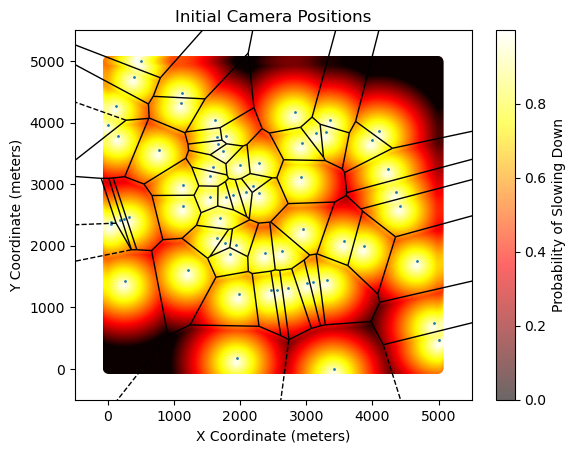

Initial Average Coverage Probability: 0.579662381826946


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_1824/3745812004.py:126: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.6044530945988493


<Figure size 1200x800 with 0 Axes>

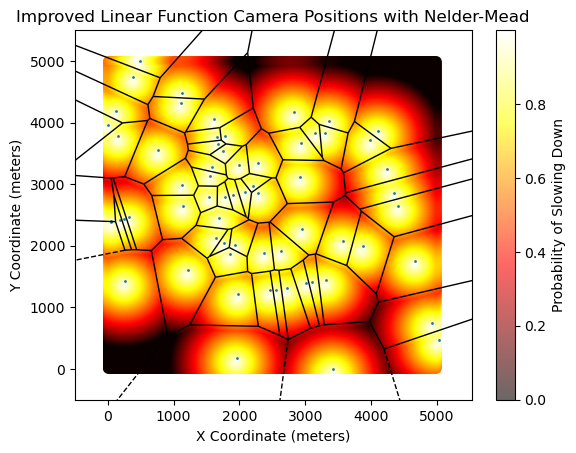

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.68, Y: -33.44)
Camera 2: (X: -70.68, Y: -33.45)
Camera 3: (X: -70.68, Y: -33.45)
Camera 4: (X: -70.67, Y: -33.43)
Camera 5: (X: -70.67, Y: -33.44)
Camera 6: (X: -70.67, Y: -33.45)
Camera 7: (X: -70.67, Y: -33.45)
Camera 8: (X: -70.67, Y: -33.46)
Camera 9: (X: -70.67, Y: -33.45)
Camera 10: (X: -70.67, Y: -33.43)
Camera 11: (X: -70.67, Y: -33.43)
Camera 12: (X: -70.67, Y: -33.44)
Camera 13: (X: -70.67, Y: -33.43)
Camera 14: (X: -70.66, Y: -33.43)
Camera 15: (X: -70.66, Y: -33.44)
Camera 16: (X: -70.66, Y: -33.45)
Camera 17: (X: -70.66, Y: -33.46)
Camera 18: (X: -70.66, Y: -33.45)
Camera 19: (X: -70.66, Y: -33.44)
Camera 20: (X: -70.66, Y: -33.44)
Camera 21: (X: -70.66, Y: -33.43)
Camera 22: (X: -70.66, Y: -33.45)
Camera 23: (X: -70.66, Y: -33.44)
Camera 24: (X: -70.66, Y: -33.44)
Camera 25: (X: -70.66, Y: -33.45)
Camera 26: (X: -70.66, Y: -33.44)
Camera 27: (X: -70.66, Y: -33.45)
Camera 28: (X: -70.66, Y: -33.45)
Camera 29: (X

NameError: name 'final_probabilities' is not defined

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon


# Record the start time
start_time = time.time()

# Load the crash data
# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points


def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Linear Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': scaled_crash_points[:, 0],
        'Initial_Y': scaled_crash_points[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Lin_Stgo_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Lin_Stgo_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)
else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

In [ ]:
#Logarithmic

<Figure size 1200x800 with 0 Axes>

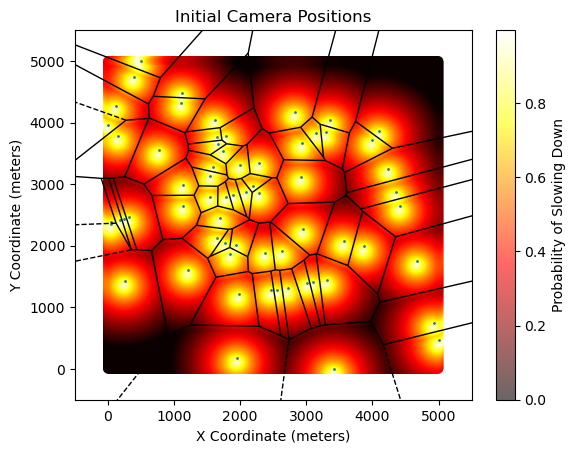

Initial Average Coverage Probability: 0.4264971596581007


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_1824/110794068.py:124: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.45660826479830363


<Figure size 1200x800 with 0 Axes>

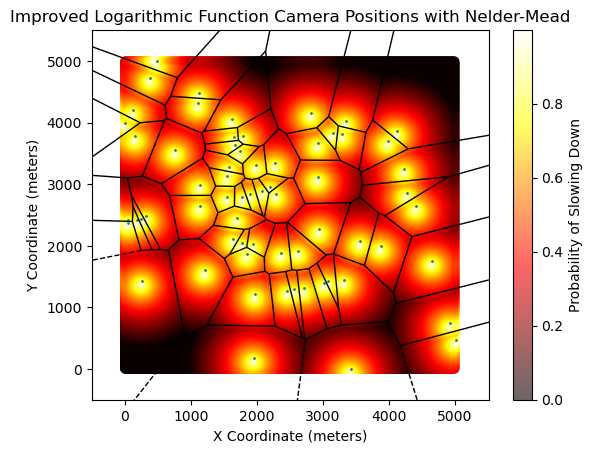

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.68, Y: -33.44)
Camera 2: (X: -70.68, Y: -33.45)
Camera 3: (X: -70.68, Y: -33.45)
Camera 4: (X: -70.67, Y: -33.43)
Camera 5: (X: -70.67, Y: -33.44)
Camera 6: (X: -70.67, Y: -33.45)
Camera 7: (X: -70.67, Y: -33.45)
Camera 8: (X: -70.67, Y: -33.46)
Camera 9: (X: -70.67, Y: -33.45)
Camera 10: (X: -70.67, Y: -33.43)
Camera 11: (X: -70.67, Y: -33.43)
Camera 12: (X: -70.67, Y: -33.44)
Camera 13: (X: -70.67, Y: -33.43)
Camera 14: (X: -70.66, Y: -33.43)
Camera 15: (X: -70.66, Y: -33.44)
Camera 16: (X: -70.66, Y: -33.45)
Camera 17: (X: -70.66, Y: -33.46)
Camera 18: (X: -70.66, Y: -33.45)
Camera 19: (X: -70.66, Y: -33.44)
Camera 20: (X: -70.66, Y: -33.44)
Camera 21: (X: -70.66, Y: -33.43)
Camera 22: (X: -70.66, Y: -33.45)
Camera 23: (X: -70.66, Y: -33.44)
Camera 24: (X: -70.66, Y: -33.44)
Camera 25: (X: -70.66, Y: -33.45)
Camera 26: (X: -70.66, Y: -33.44)
Camera 27: (X: -70.66, Y: -33.45)
Camera 28: (X: -70.66, Y: -33.45)
Camera 29: (X

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon


# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points


def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Logarithmic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

# Save to CSV
#output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Nelder-Mead/N_M_Lin.csv'  # Adjust the path as necessary
#camera_positions_df.to_csv(output_csv_path, index=False)

#print(f"Camera positions saved to {output_csv_path}")

# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': scaled_crash_points[:, 0],
        'Initial_Y': scaled_crash_points[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Log_Stgo_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Log_Stgo_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)
else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

In [ ]:
#Quadratic

<Figure size 1200x800 with 0 Axes>

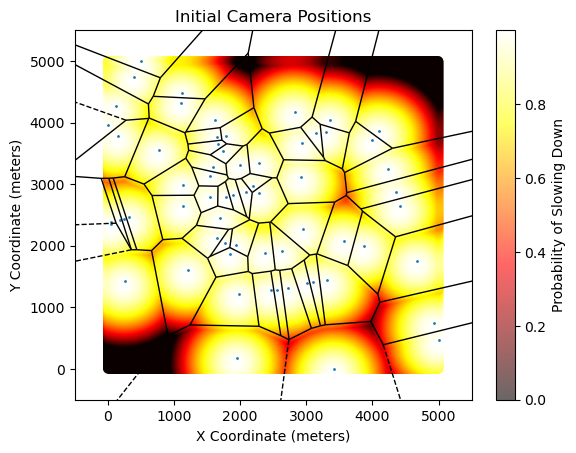

Initial Average Coverage Probability: 0.7380033419441029


/var/folders/vq/_4vyrs956z78dt4gf5_mzj6w0000gn/T/ipykernel_1824/1342496821.py:125: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})


Optimized Average Coverage Probability: 0.7730124952668167


<Figure size 1200x800 with 0 Axes>

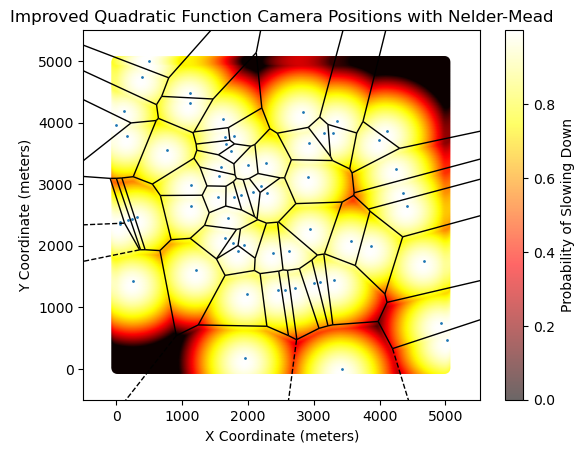

Camera Positions in Longitude and Latitude:
Camera 1: (X: -70.68, Y: -33.44)
Camera 2: (X: -70.68, Y: -33.45)
Camera 3: (X: -70.68, Y: -33.45)
Camera 4: (X: -70.67, Y: -33.43)
Camera 5: (X: -70.67, Y: -33.44)
Camera 6: (X: -70.67, Y: -33.45)
Camera 7: (X: -70.67, Y: -33.45)
Camera 8: (X: -70.67, Y: -33.46)
Camera 9: (X: -70.67, Y: -33.45)
Camera 10: (X: -70.67, Y: -33.43)
Camera 11: (X: -70.67, Y: -33.43)
Camera 12: (X: -70.67, Y: -33.44)
Camera 13: (X: -70.67, Y: -33.43)
Camera 14: (X: -70.66, Y: -33.43)
Camera 15: (X: -70.66, Y: -33.44)
Camera 16: (X: -70.66, Y: -33.45)
Camera 17: (X: -70.66, Y: -33.46)
Camera 18: (X: -70.66, Y: -33.45)
Camera 19: (X: -70.66, Y: -33.44)
Camera 20: (X: -70.66, Y: -33.44)
Camera 21: (X: -70.66, Y: -33.43)
Camera 22: (X: -70.66, Y: -33.45)
Camera 23: (X: -70.66, Y: -33.44)
Camera 24: (X: -70.66, Y: -33.44)
Camera 25: (X: -70.66, Y: -33.45)
Camera 26: (X: -70.66, Y: -33.44)
Camera 27: (X: -70.66, Y: -33.45)
Camera 28: (X: -70.66, Y: -33.45)
Camera 29: (X

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
import time
from scipy.stats import wilcoxon


# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'SANTIAGO']  # Filter for Providencia
provi_df = provi_df[~((provi_df['X'].round(7) == -70.8574927) & (provi_df['Y'].round(7) == -33.609812))]
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points


def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)

# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


# Objective function to maximize the average probability of slowing down
def objective_function(camera_positions_flat, grid_points, area_size):
    camera_positions = camera_positions_flat.reshape(-1, 2)
    # Calculate the average coverage using the existing `calculate_voronoi_coverage` function
    negative_avg_probability = -calculate_voronoi_coverage(grid_points, camera_positions)
    return negative_avg_probability

# Function to optimize camera positions using the Nelder-Mead algorithm
def optimize_camera_positions_nelder_mead(initial_camera_positions, grid_points, area_size):
    # Flatten the initial_camera_positions for the optimizer
    initial_positions_flat = initial_camera_positions.flatten()
    # Run the Nelder-Mead optimization
    result = minimize(objective_function, initial_positions_flat, args=(grid_points, area_size), method='Nelder-Mead', options={'disp': True, 'maxiter': 1000})
    # Reshape the result to the original shape
    optimized_positions = result.x.reshape(-1, 2)
    return optimized_positions

# Example of optimizing camera positions
optimized_camera_positions = optimize_camera_positions_nelder_mead(camera_positions, grid_points, area_size)

# After optimization, you can calculate the average probability and plot the results as before
final_avg_probability = calculate_voronoi_coverage(grid_points, optimized_camera_positions)
final_probabilities = calculate_voronoi_coverage(grid_points, optimized_camera_positions, return_individual=True)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")

# Plot the optimized camera positions
probabilities = probability_of_slowing(np.min(pairwise_distances(grid_points, optimized_camera_positions), axis=1))
plot_voronoi(optimized_camera_positions, probabilities, 'Improved Quadratic Function Camera Positions with Nelder-Mead')

# Convert optimized camera positions back to original coordinates
original_camera_positions = scaler.inverse_transform(optimized_camera_positions)
print("Camera Positions in Longitude and Latitude:")
for i, pos in enumerate(original_camera_positions):
    print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
# Convert to DataFrame
camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])


# Calculate the total execution time
end_time = time.time()
total_time = end_time - start_time

# Print the total execution time
print(f"Total execution time: {total_time:.2f} seconds")
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': scaled_crash_points[:, 0],
        'Initial_Y': scaled_crash_points[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': optimized_camera_positions[:, 0],
        'Final_Y': optimized_camera_positions[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Quad_Stgo_Positions.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
    output_csv_path2 = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/NM/Santiago/NM_Quad_Stgo_HT.csv'  # Adjust the path as necessary
    comparison_df.to_csv(output_csv_path2, index=False)
else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")